In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('project2.csv',encoding='latin1')

In [4]:
df.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
#for rfm analysis it is important to drop all na values 
df.dropna(axis=0,inplace=True)

In [10]:
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [11]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [14]:
reference_date = df['InvoiceDate'].max()
recency_df = df.groupby('CustomerID').agg({'InvoiceDate': lambda x : (reference_date - x.max()).days})
recency_df.rename(columns = {'InvoiceDate':'Recency'},inplace=True)

In [15]:
print(recency_df)

            Recency
CustomerID         
12346.0         325
12347.0           1
12348.0          74
12349.0          18
12350.0         309
...             ...
18280.0         277
18281.0         180
18282.0           7
18283.0           3
18287.0          42

[4372 rows x 1 columns]


In [16]:
df = df.merge(recency_df,on='CustomerID',how='left')

In [17]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,301
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,301
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301


In [18]:
freq_df = df.groupby('CustomerID').agg({'InvoiceNo': 'count'}).rename(columns={'InvoiceNo':'Frequency'})
freq_df = freq_df.reset_index()


In [19]:
print(freq_df)

      CustomerID  Frequency
0        12346.0          2
1        12347.0        182
2        12348.0         31
3        12349.0         73
4        12350.0         17
...          ...        ...
4367     18280.0         10
4368     18281.0          7
4369     18282.0         13
4370     18283.0        756
4371     18287.0         70

[4372 rows x 2 columns]


In [20]:
df = df.merge(freq_df,on='CustomerID',how='left')

In [21]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Recency,Frequency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,301,312
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,301,312
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312


In [22]:
df['TP'] = df['Quantity']*df['UnitPrice']

In [23]:
df['TP']

0         15.30
1         20.34
2         22.00
3         20.34
4         20.34
          ...  
406824    10.20
406825    12.60
406826    16.60
406827    16.60
406828    14.85
Name: TP, Length: 406829, dtype: float64

In [24]:
total_df = df.groupby('CustomerID').agg({'TP':'sum'}).rename(columns = {'TP':'Total_Spent'})
total_df = total_df.reset_index()

In [25]:
print(total_df)

      CustomerID  Total_Spent
0        12346.0         0.00
1        12347.0      4310.00
2        12348.0      1797.24
3        12349.0      1757.55
4        12350.0       334.40
...          ...          ...
4367     18280.0       180.60
4368     18281.0        80.82
4369     18282.0       176.60
4370     18283.0      2094.88
4371     18287.0      1837.28

[4372 rows x 2 columns]


In [26]:
df = df.merge(total_df,on='CustomerID',how='left')

In [27]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Recency,Frequency,TP,Total_Spent
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,301,312,15.30,5288.63
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312,20.34,5288.63
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,301,312,22.00,5288.63
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312,20.34,5288.63
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312,20.34,5288.63


In [28]:
recencythreshold = df['Recency'].quantile([0.25,0.5,0.75])
frequencythreshold = df['Frequency'].quantile([0.25,0.5,0.75])
totalthreshold = df['Total_Spent'].quantile([0.25,0.5,0.75])

def classify_loyalty(row, recencythreshold, frequencythreshold, totalthreshold):
  
    if row['Recency'] <= recencythreshold[0.25]:
        recency_score = 4
    elif row['Recency'] <= recencythreshold[0.50]:
        recency_score = 3
    elif row['Recency'] <= recencythreshold[0.75]:
        recency_score = 2
    else:
        recency_score = 1

    
    if row['Frequency'] <= frequencythreshold[0.25]:
        frequency_score = 1
    elif row['Frequency'] <= frequencythreshold[0.50]:
        frequency_score = 2
    elif row['Frequency'] <= frequencythreshold[0.75]:
        frequency_score = 3
    else:
        frequency_score = 4

    if row['Total_Spent'] <= totalthreshold[0.25]:
        monetary_score = 1
    elif row['Total_Spent'] <= totalthreshold[0.50]:
        monetary_score = 2
    elif row['Total_Spent'] <= totalthreshold[0.75]:
        monetary_score = 3
    else:
        monetary_score = 4


    rfm_score = int(f"{recency_score}{frequency_score}{monetary_score}")


    if rfm_score >= 444:
        loyalty = "Champions"
    elif rfm_score >= 333:
        loyalty = "Loyal Customers"
    elif rfm_score >= 222:
        loyalty = "Potential Loyalists"
    else:
        loyalty = "Needs Attention"

    return loyalty


In [29]:
df['Loyalty'] = df.apply(classify_loyalty, axis=1, recencythreshold=recencythreshold, frequencythreshold=frequencythreshold,totalthreshold=totalthreshold)


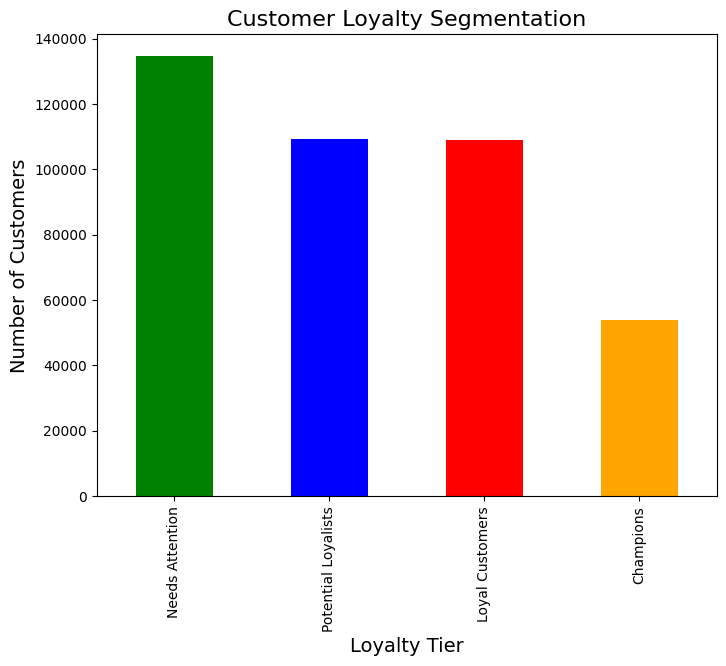

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
df['Loyalty'].value_counts().plot(kind='bar', color=['green', 'blue', 'red','orange'])
plt.title('Customer Loyalty Segmentation', fontsize=16)
plt.xlabel('Loyalty Tier', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.show()

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


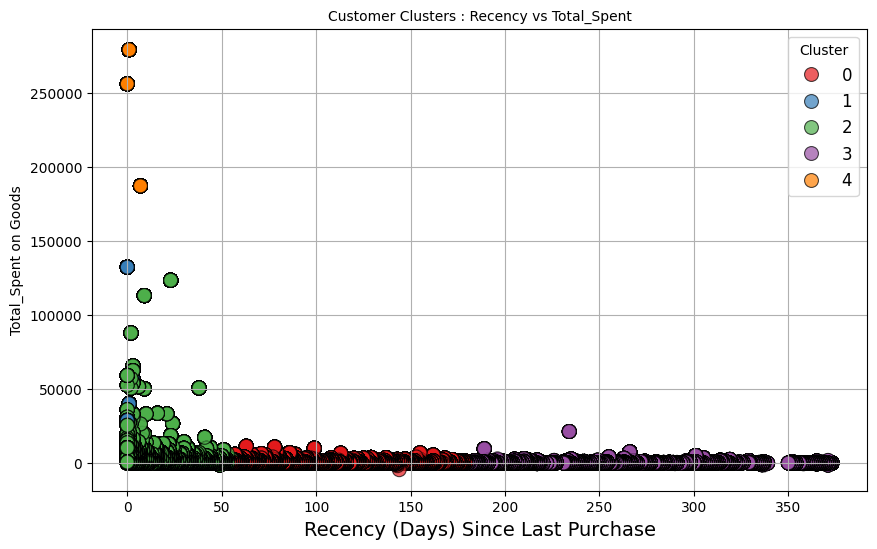

In [32]:
#No of cluster is 5
clustering_data = df[['Recency','Total_Spent','Frequency']]
scaler = MinMaxScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(clustering_data_scaled)
df['Cluster'] = kmeans.fit_predict(clustering_data_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Recency',y='Total_Spent',hue='Cluster',palette = 'Set1',s=100,alpha=0.7,edgecolor='k')
plt.title('Customer Clusters : Recency vs Total_Spent',fontsize=10)
plt.xlabel('Recency (Days) Since Last Purchase',fontsize=14) 
plt.ylabel('Total_Spent on Goods',fontsize=10) 
plt.legend(title='Cluster', loc='upper right', fontsize=12)
plt.grid(True)
plt.show()    

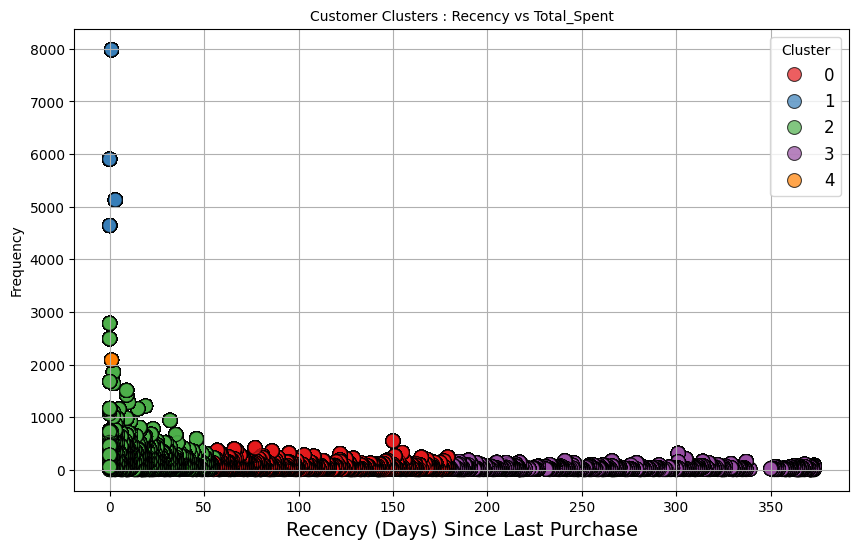

In [33]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Recency',y='Frequency',hue='Cluster',palette = 'Set1',s=100,alpha=0.7,edgecolor='k')
plt.title('Customer Clusters : Recency vs Total_Spent',fontsize=10)
plt.xlabel('Recency (Days) Since Last Purchase',fontsize=14) 
plt.ylabel('Frequency',fontsize=10) 
plt.legend(title='Cluster', loc='upper right', fontsize=12)
plt.grid(True)
plt.show()    

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


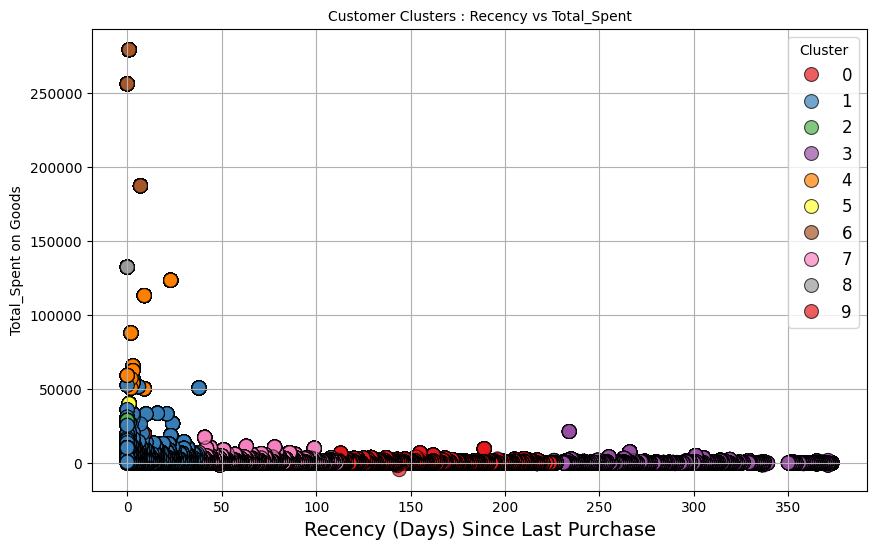

In [34]:
#no of clusters is 10
clustering_data = df[['Recency','Total_Spent','Frequency']]
scaler = MinMaxScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)
kmeans = KMeans(n_clusters=10,random_state=42)
kmeans.fit(clustering_data_scaled)
df['Cluster'] = kmeans.fit_predict(clustering_data_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Recency',y='Total_Spent',hue='Cluster',palette = 'Set1',s=100,alpha=0.7,edgecolor='k')
plt.title('Customer Clusters : Recency vs Total_Spent',fontsize=10)
plt.xlabel('Recency (Days) Since Last Purchase',fontsize=14) 
plt.ylabel('Total_Spent on Goods',fontsize=10) 
plt.legend(title='Cluster', loc='upper right', fontsize=12)
plt.grid(True)
plt.show()    

No we take 10 Clusters


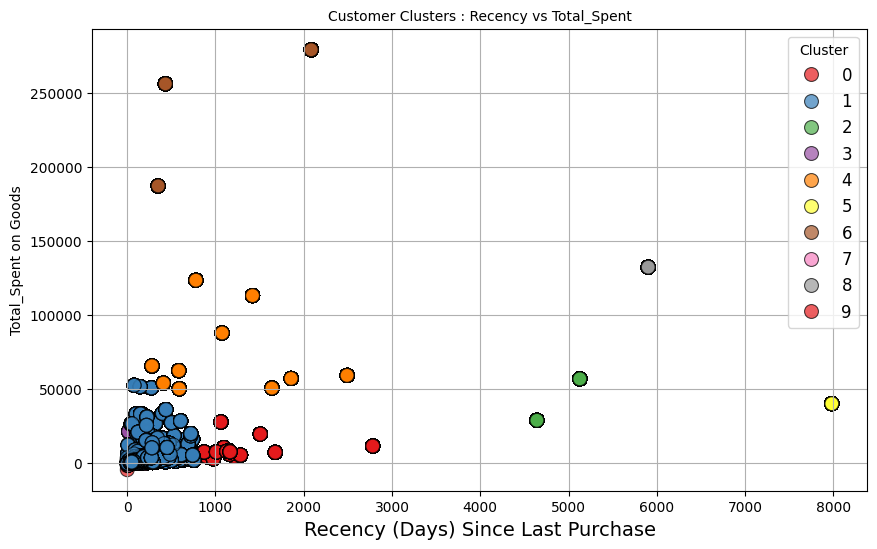

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='Frequency',y='Total_Spent',hue='Cluster',palette = 'Set1',s=100,alpha=0.7,edgecolor='k')
plt.title('Customer Clusters : Recency vs Total_Spent',fontsize=10)
plt.xlabel('Recency (Days) Since Last Purchase',fontsize=14) 
plt.ylabel('Total_Spent on Goods',fontsize=10) 
plt.legend(title='Cluster', loc='upper right', fontsize=12)
plt.grid(True)
plt.show() 

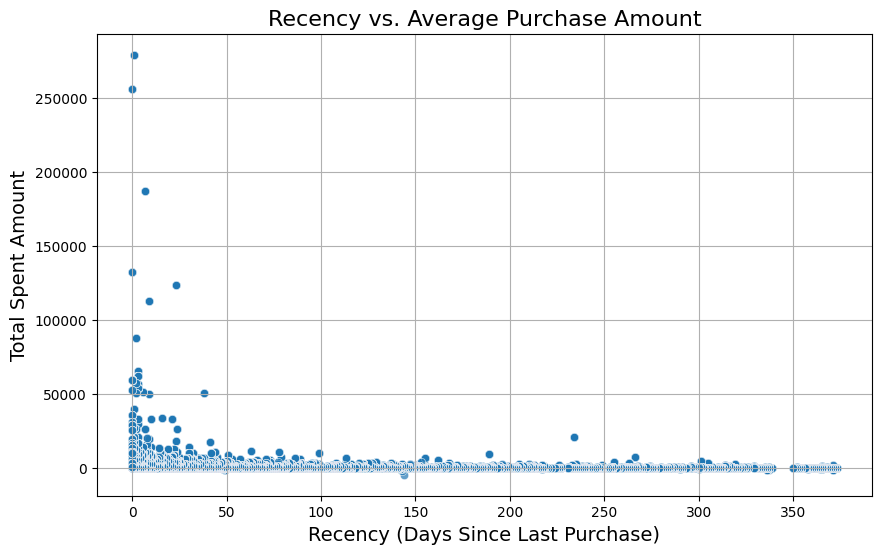

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Recency', y='Total_Spent', alpha=0.7)
plt.title('Recency vs. Average Purchase Amount', fontsize=16)
plt.xlabel('Recency (Days Since Last Purchase)', fontsize=14)
plt.ylabel('Total Spent Amount', fontsize=14)
plt.grid(True)
plt.show()

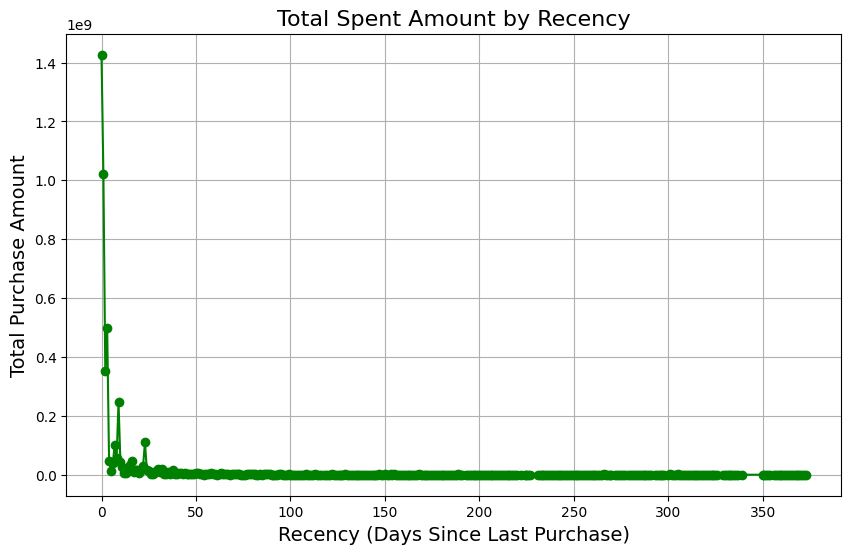

In [37]:
recency_total = df.groupby('Recency')['Total_Spent'].sum()

plt.figure(figsize=(10, 6))
recency_total.plot(kind='line', color='green', marker='o')
plt.title('Total Spent Amount by Recency', fontsize=16)
plt.xlabel('Recency (Days Since Last Purchase)', fontsize=14)
plt.ylabel('Total Purchase Amount', fontsize=14)
plt.grid(True)
plt.show()


In [38]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Recency,Frequency,TP,Total_Spent,Loyalty,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,301,312,15.30,5288.63,Needs Attention,3
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312,20.34,5288.63,Needs Attention,3
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,301,312,22.00,5288.63,Needs Attention,3


In [39]:
df['Loyalty'].value_counts()

Loyalty
Needs Attention        134675
Potential Loyalists    109282
Loyal Customers        109034
Champions               53838
Name: count, dtype: int64

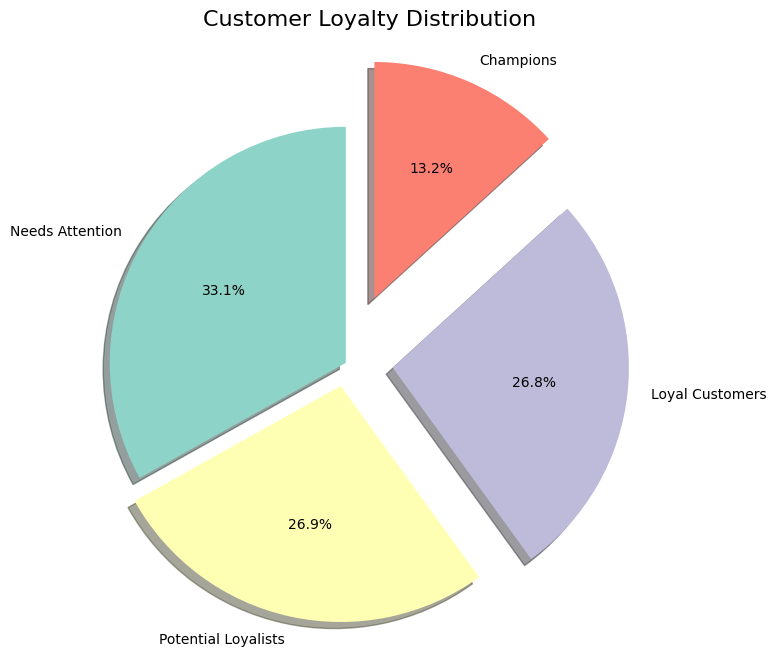

In [40]:
labels = df['Loyalty'].unique()  
sizes = df['Loyalty'].value_counts()  
explode = [0,0.1,0.2,0.3]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', len(labels)),shadow=True,explode=explode)
ax.axis('equal')
plt.title('Customer Loyalty Distribution', fontsize=16)
plt.show()




In [41]:
df['Country'].value_counts()

Country
United Kingdom          361878
Germany                   9495
France                    8491
EIRE                      7485
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               1877
Portugal                  1480
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
USA                        291
Israel                     250
Unspecified                244
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58
Lebanon                     45


In [42]:
import matplotlib.pyplot as plt

<Axes: xlabel='Country'>

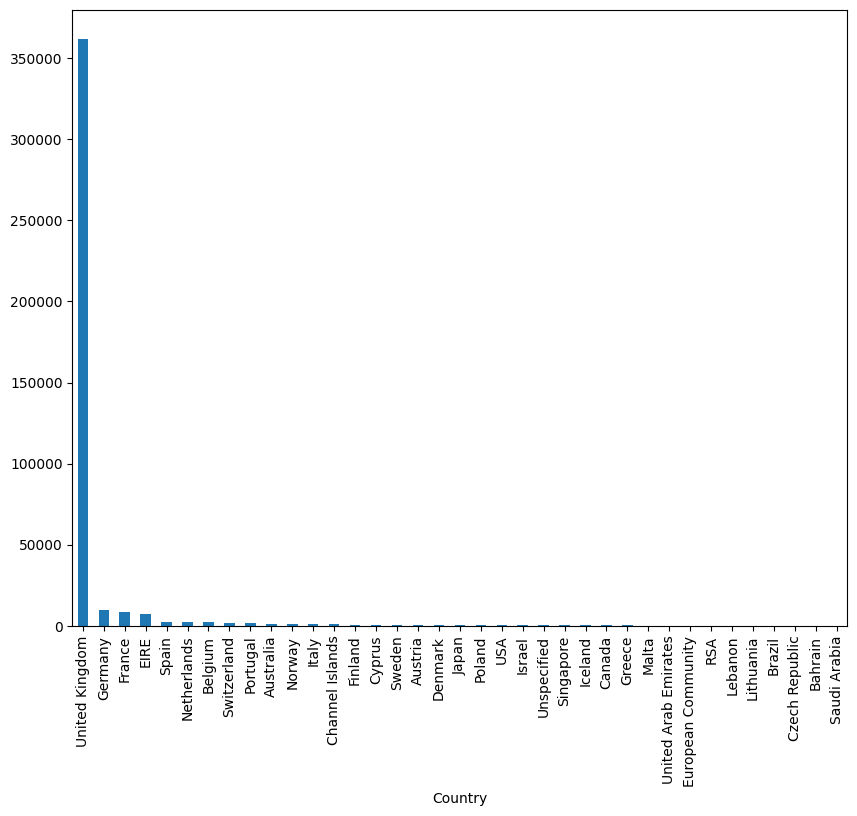

In [43]:
plt.figure(figsize=(10,8))
df['Country'].value_counts().plot(kind='bar')


In [44]:
df['Year'] = df['InvoiceDate'].dt.year

In [45]:
df['Month'] = df['InvoiceDate'].dt.month

In [46]:
df['Day'] = df['InvoiceDate'].dt.day

In [47]:
df['Week'] = df['InvoiceDate'].dt.isocalendar().week

In [48]:
df['Day_of_Week'] = df['InvoiceDate'].dt.dayofweek
df['Quarter'] = df['InvoiceDate'].dt.quarter

In [49]:
monthly_trends = df.groupby('Month')['Total_Spent'].mean()
weekly_trends = df.groupby('Week')['Total_Spent'].mean()

Text(0, 0.5, 'Value')

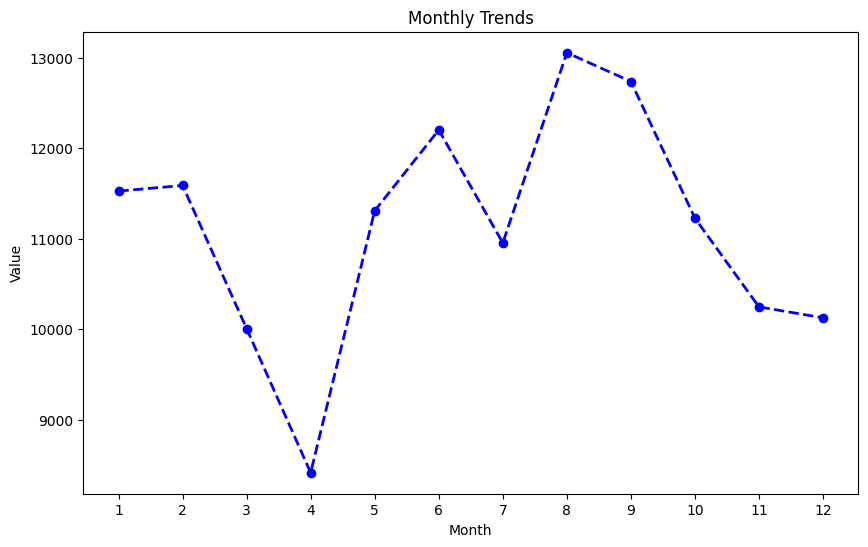

In [50]:
plt.figure(figsize=(10,6))
monthly_trends.plot(kind='line',marker='o',color='b',linestyle='--',linewidth=2)
plt.title('Monthly Trends')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Value')

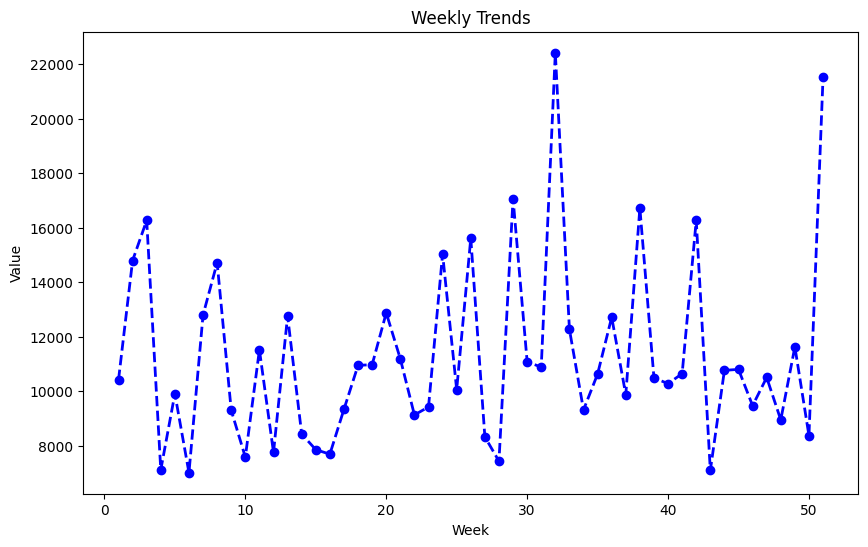

In [51]:
plt.figure(figsize=(10,6))
weekly_trends.plot(kind='line',marker='o',color='b',linestyle='--',linewidth=2)
plt.title('Weekly Trends')
plt.xlabel('Week')
plt.ylabel('Value')
plt.show()

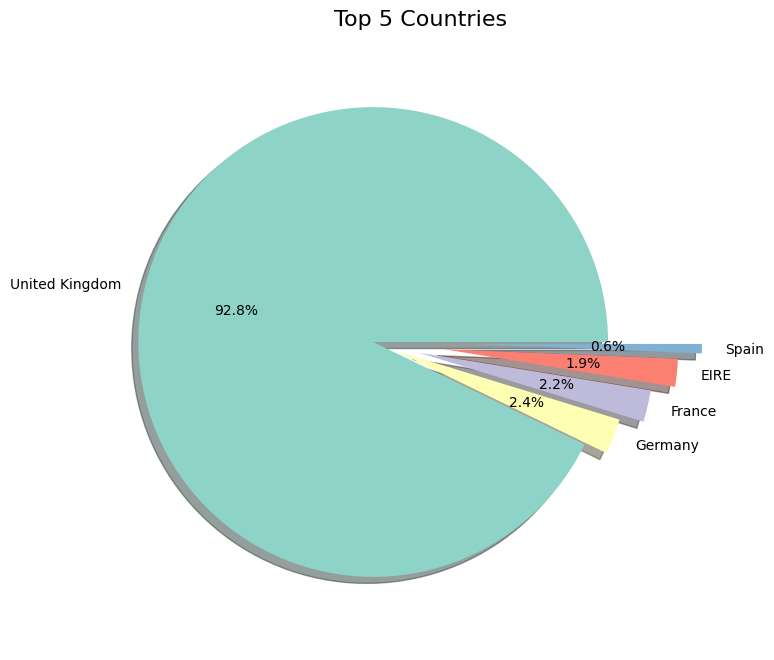

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = df['Country'].value_counts().head(5).index 
sizes = df['Country'].value_counts().head(5).values 
explode = [0, 0.1, 0.2, 0.3, 0.4]  

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=sns.color_palette('Set3', len(labels)), 
       shadow=True, explode=explode)


ax.axis('equal')
plt.title('Top 5 Countries', fontsize=16)
plt.show()


In [53]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Recency,Frequency,TP,Total_Spent,Loyalty,Cluster,Year,Month,Day,Week,Day_of_Week,Quarter
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,301,312,15.30,5288.63,Needs Attention,3,2010,12,1,48,2,4
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,301,312,20.34,5288.63,Needs Attention,3,2010,12,1,48,2,4


In [55]:
df['Description'].value_counts()[:10]

Description
WHITE HANGING HEART T-LIGHT HOLDER    2070
REGENCY CAKESTAND 3 TIER              1905
JUMBO BAG RED RETROSPOT               1662
ASSORTED COLOUR BIRD ORNAMENT         1418
PARTY BUNTING                         1416
LUNCH BAG RED RETROSPOT               1358
SET OF 3 CAKE TINS PANTRY DESIGN      1232
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1126
PACK OF 72 RETROSPOT CAKE CASES       1080
Name: count, dtype: int64

In [58]:
df['Total_Spent'].value_counts()

Total_Spent
 40340.78     7983
 132572.62    5903
 57120.91     5128
 29072.10     4642
 11713.85     2782
              ... 
-3.75            1
 3.75            1
 244.08          1
 34.00           1
 85.00           1
Name: count, Length: 4288, dtype: int64

In [59]:
df['Month'].value_counts()[:5]

Month
11    65598
10    50695
12    44511
9     40822
5     28908
Name: count, dtype: int64

In [60]:
df['Total_Spent'].sum()

4502514063.049

In [61]:
df['InvoiceNo'].nunique()

22190

In [62]:
df['Frequency'].value_counts()

Frequency
7983    7983
5903    5903
5128    5128
4642    4642
2782    2782
        ... 
187      187
178      178
3        159
2        118
1         79
Name: count, Length: 474, dtype: int64

In [63]:
df['Total_Spent'].max()

279489.02

Conclusion
1) The Top 5 Countries to where the Goods are sold are The UK,Germany.France,EIRE,Spain
2) The most sold item among the descriptions given to us is  "WHITE HANGING HEART T-LIGHT HOLDER" and about 2070 of these were sold.
3) The Start of the year which is the first quarter is not always good for business as trends show that the first few months always show a dip in sales.
4) The most amount of Money spent is 279489.02 Euros
5) April is the Month where the least sales happen and is the least selling month out of the 12 months.
6) The Second Quarter shows life with a sharp increase in Sales
7) The most amount of money spent is in the month of August.
8) About 50000 Customers fall into the Champion Category of Customers which means that they are regular buyers and active spenders.
9) The average order value is 23.45 Euros
10) The average order frequency is 2.45 times per year.
11) There are almost the same no of customers in the "Potential Loyalists" and "Loyal Customers" which means that they constitute about almost 50% of the total customers.
12) The "Champion" category of customers are the most profitable customers.
